# Estimação de Parâmetros do Alimentador — Regressão Multi-Target

Estima a matriz de impedância trifásica `[r11, r12, r22, r13, r23, r33, x11, x12, x22, x13, x23, x33]`  
a partir de medições de tensão, corrente e potência nos dois nós do alimentador.

In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.base import clone
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (GradientBoostingRegressor,
                               RandomForestRegressor,
                               ExtraTreesRegressor)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

SEED = 42

def mape_per_target(y_true, y_pred):
    """MAPE (%) calculado coluna a coluna — evita médias cruzadas entre targets."""
    return np.mean(np.abs((y_true - y_pred) / y_true), axis=0) * 100

## 1. Carga e inspeção dos dados

In [2]:
df = pd.read_csv('resultados_completos_0.01.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 48)


,r11,r12,r22,r13,r23,r33,x11,x12,x22,x13,...,I1_mag_faseB,I1_ang_faseB,I1_mag_faseC,I1_ang_faseC,I2_mag_faseA,I2_ang_faseA,I2_mag_faseB,I2_ang_faseB,I2_mag_faseC,I2_ang_faseC
0,0.347844,0.155813,0.334539,0.158830,0.151783,0.343622,1.032914,0.492856,1.061910,0.423621,...,419.460,-141.40,591.660,93.41,563.059,151.19,419.461,38.60,591.661,-86.59
1,0.347276,0.156226,0.341095,0.157745,0.154151,0.342203,1.010191,0.493998,1.033069,0.423300,...,419.207,-141.27,591.786,93.41,562.323,151.35,419.207,38.73,591.786,-86.59
2,0.342861,0.155914,0.336783,0.157673,0.151452,0.344504,1.032487,0.495806,1.041401,0.424497,...,419.235,-141.34,592.082,93.36,562.830,151.20,419.235,38.66,592.083,-86.64


In [4]:
df.columns

Index(['r11', 'r12', 'r22', 'r13', 'r23', 'r33', 'x11', 'x12', 'x22', 'x13',
       'x23', 'x33', 'P1_faseA', 'Q1_faseA', 'P1_faseB', 'Q1_faseB',
       'P1_faseC', 'Q1_faseC', 'P2_faseA', 'Q2_faseA', 'P2_faseB', 'Q2_faseB',
       'P2_faseC', 'Q2_faseC', 'V1_mag_RG60', 'V1_ang_RG60', 'V2_mag_RG60',
       'V2_ang_RG60', 'V3_mag_RG60', 'V3_ang_RG60', 'V1_mag_632', 'V1_ang_632',
       'V2_mag_632', 'V2_ang_632', 'V3_mag_632', 'V3_ang_632', 'I1_mag_faseA',
       'I1_ang_faseA', 'I1_mag_faseB', 'I1_ang_faseB', 'I1_mag_faseC',
       'I1_ang_faseC', 'I2_mag_faseA', 'I2_ang_faseA', 'I2_mag_faseB',
       'I2_ang_faseB', 'I2_mag_faseC', 'I2_ang_faseC'],
      dtype='object')

# Apenas as features de entrada (Tensão e corrente na entrada)

In [5]:
df = df[
    [
        # Potências de entrada
        'P1_faseA', 'Q1_faseA',
        'P1_faseB', 'Q1_faseB',
        'P1_faseC', 'Q1_faseC',

        # Potências de saída
        'P2_faseA', 'Q2_faseA',
        'P2_faseB', 'Q2_faseB',
        'P2_faseC', 'Q2_faseC',

        # Tensões na entrada (RG60)
        'V1_mag_RG60', 'V1_ang_RG60',
        'V2_mag_RG60', 'V2_ang_RG60',
        'V3_mag_RG60', 'V3_ang_RG60',

        # Correntes na entrada
        'I1_mag_faseA', 'I1_ang_faseA',
        'I1_mag_faseB', 'I1_ang_faseB',
        'I1_mag_faseC', 'I1_ang_faseC',

        # Targets
        'r11', 'r12', 'r22',
        'r13', 'r23', 'r33',
        'x11', 'x12', 'x22',
        'x13', 'x23', 'x33'
    ]
].copy()

print(df.columns.tolist())
print(df.shape)

['P1_faseA', 'Q1_faseA', 'P1_faseB', 'Q1_faseB', 'P1_faseC', 'Q1_faseC', 'P2_faseA', 'Q2_faseA', 'P2_faseB', 'Q2_faseB', 'P2_faseC', 'Q2_faseC', 'V1_mag_RG60', 'V1_ang_RG60', 'V2_mag_RG60', 'V2_ang_RG60', 'V3_mag_RG60', 'V3_ang_RG60', 'I1_mag_faseA', 'I1_ang_faseA', 'I1_mag_faseB', 'I1_ang_faseB', 'I1_mag_faseC', 'I1_ang_faseC', 'r11', 'r12', 'r22', 'r13', 'r23', 'r33', 'x11', 'x12', 'x22', 'x13', 'x23', 'x33']
(10000, 36)


In [6]:
TARGETS = ['r11','r12','r22','r13','r23','r33',
           'x11','x12','x22','x13','x23','x33']

FEATURES = [c for c in df.columns if c not in TARGETS]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Targets  ({len(TARGETS)}): {TARGETS}')

Features (24): ['P1_faseA', 'Q1_faseA', 'P1_faseB', 'Q1_faseB', 'P1_faseC', 'Q1_faseC', 'P2_faseA', 'Q2_faseA', 'P2_faseB', 'Q2_faseB', 'P2_faseC', 'Q2_faseC', 'V1_mag_RG60', 'V1_ang_RG60', 'V2_mag_RG60', 'V2_ang_RG60', 'V3_mag_RG60', 'V3_ang_RG60', 'I1_mag_faseA', 'I1_ang_faseA', 'I1_mag_faseB', 'I1_ang_faseB', 'I1_mag_faseC', 'I1_ang_faseC']
Targets  (12): ['r11', 'r12', 'r22', 'r13', 'r23', 'r33', 'x11', 'x12', 'x22', 'x13', 'x23', 'x33']


In [ ]:
df[TARGETS].describe().round(5)

,r11,r12,r22,r13,r23,r33,x11,x12,x22,x13,x23,x33
count,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000
mean,0.34651,0.15599,0.33751,0.15796,0.15347,0.34142,1.01790,0.50169,1.04786,0.42356,0.38488,1.03485
std,0.00346,0.00155,0.00336,0.00156,0.00154,0.00337,0.01026,0.00503,0.01053,0.00421,0.00383,0.01021
min,0.33448,0.15057,0.32355,0.15142,0.14702,0.32655,0.98215,0.48358,1.01149,0.40838,0.36891,0.99419
25%,0.34418,0.15495,0.33526,0.15689,0.15243,0.33915,1.01105,0.49830,1.04067,0.42067,0.38226,1.02788
50%,0.34649,0.15601,0.33751,0.15796,0.15349,0.34141,1.01774,0.50170,1.04793,0.42354,0.38486,1.03480
75%,0.34881,0.15703,0.33978,0.15900,0.15451,0.34371,1.02494,0.50515,1.05502,0.42644,0.38745,1.04184
max,0.35993,0.16199,0.35071,0.16370,0.15942,0.35461,1.06180,0.52163,1.09792,0.44119,0.40047,1.07207


## 2. Correlação features × targets

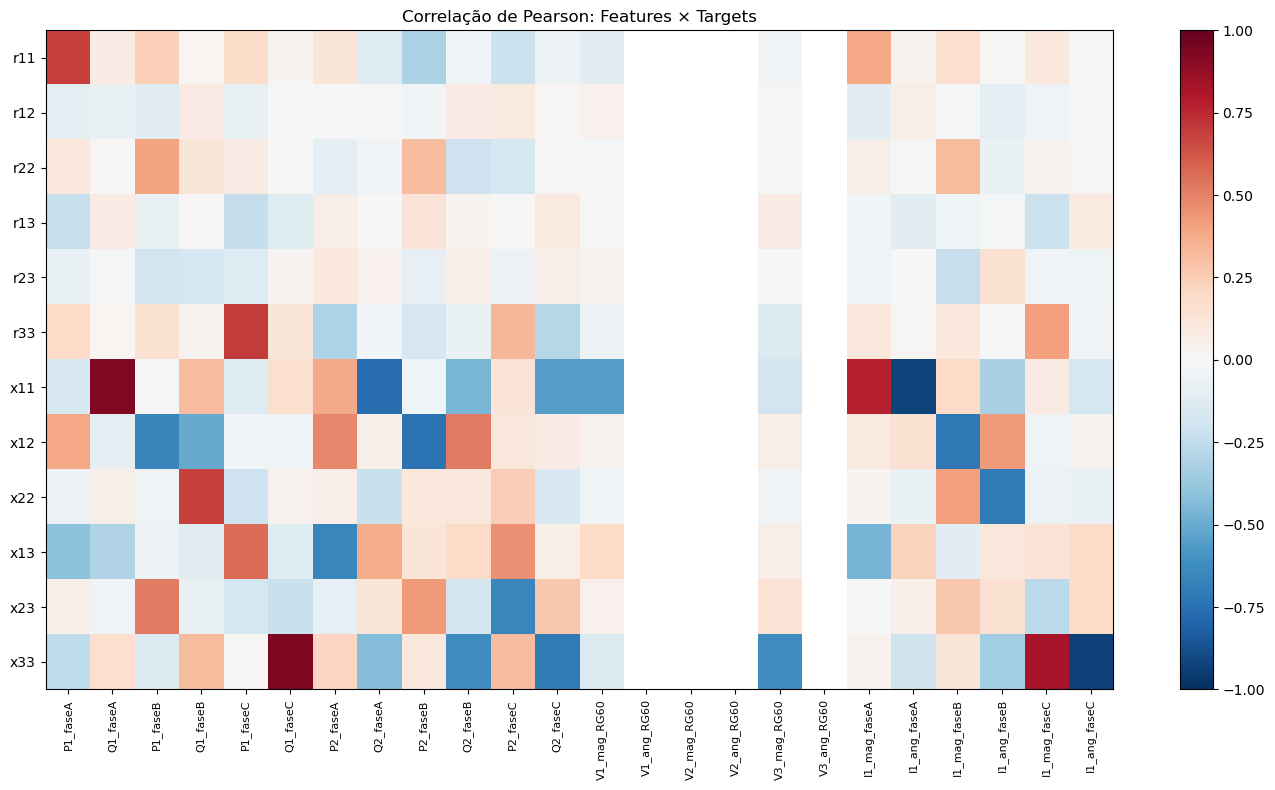

In [8]:
corr = df[FEATURES + TARGETS].corr().loc[FEATURES, TARGETS]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(corr.T.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=90, fontsize=8)
ax.set_yticks(range(len(TARGETS)))
ax.set_yticklabels(TARGETS)
ax.set_title('Correlação de Pearson: Features × Targets')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 3. Divisão treino / teste e normalização

In [9]:
X = df[FEATURES].values
y = df[TARGETS].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Treino: {X_train_s.shape}  |  Teste: {X_test_s.shape}')

Treino: (8000, 24)  |  Teste: (2000, 24)


## 4. Modelos

In [10]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': MultiOutputRegressor(
        RandomForestRegressor(n_estimators=200, max_depth=None,
                              n_jobs=-1, random_state=SEED)
    ),
    'ExtraTrees': MultiOutputRegressor(
        ExtraTreesRegressor(n_estimators=200, max_depth=None,
                            n_jobs=-1, random_state=SEED)
    ),
    'GradientBoosting': MultiOutputRegressor(
        GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                  learning_rate=0.05, random_state=SEED)
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}

for name, model in models.items():
    print(f'\nTreinando {name} com validação cruzada...')

    r2_folds = []
    mae_folds = []
    rmse_folds = []
    mape_folds = []

    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', clone(model))
        ])

        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_val)

        r2 = r2_score(y_val, y_pred, multioutput='raw_values')
        mae = mean_absolute_error(y_val, y_pred, multioutput='raw_values')
        rmse = np.sqrt(mean_squared_error(y_val, y_pred, multioutput='raw_values'))
        mape = mape_per_target(y_val, y_pred)

        r2_folds.append(r2)
        mae_folds.append(mae)
        rmse_folds.append(rmse)
        mape_folds.append(mape)

    r2_folds = np.array(r2_folds)
    mae_folds = np.array(mae_folds)
    rmse_folds = np.array(rmse_folds)
    mape_folds = np.array(mape_folds)

    cv_results[name] = {
        'r2_mean': r2_folds.mean(axis=0),
        'r2_std': r2_folds.std(axis=0),
        'mae_mean': mae_folds.mean(axis=0),
        'mae_std': mae_folds.std(axis=0),
        'rmse_mean': rmse_folds.mean(axis=0),
        'rmse_std': rmse_folds.std(axis=0),
        'mape_mean': mape_folds.mean(axis=0),
        'mape_std': mape_folds.std(axis=0),
    }

    print(f"R² médio   = {r2_folds.mean():.4f} ± {r2_folds.mean(axis=1).std():.4f}")
    print(f"MAE médio  = {mae_folds.mean():.6f} ± {mae_folds.mean(axis=1).std():.6f}")
    print(f"RMSE médio = {rmse_folds.mean():.6f} ± {rmse_folds.mean(axis=1).std():.6f}")
    print(f"MAPE médio = {mape_folds.mean():.4f}% ± {mape_folds.mean(axis=1).std():.4f}%")


Treinando Ridge com validação cruzada...
R² médio   = 0.8328 ± 0.0018
MAE médio  = 0.000912 ± 0.000010
RMSE médio = 0.001143 ± 0.000011
MAPE médio = 0.2711% ± 0.0029%

Treinando RandomForest com validação cruzada...
R² médio   = 0.5110 ± 0.0010
MAE médio  = 0.001947 ± 0.000005
RMSE médio = 0.002443 ± 0.000006
MAPE médio = 0.5198% ± 0.0022%

Treinando ExtraTrees com validação cruzada...
R² médio   = 0.4973 ± 0.0008
MAE médio  = 0.001977 ± 0.000006
RMSE médio = 0.002478 ± 0.000007
MAPE médio = 0.5273% ± 0.0023%

Treinando GradientBoosting com validação cruzada...
R² médio   = 0.5250 ± 0.0024
MAE médio  = 0.001902 ± 0.000009
RMSE médio = 0.002384 ± 0.000009
MAPE médio = 0.5110% ± 0.0027%


## 5. Comparação de métricas por target

In [11]:
metric_labels = {
    'r2':   'R²     (maior = melhor)',
    'mae':  'MAE    (menor = melhor)',
    'rmse': 'RMSE   (menor = melhor)',
    'mape': 'MAPE % (menor = melhor)',
}

for metric, label in metric_labels.items():

    rows_mean = {
        name: cv_results[name][f'{metric}_mean']
        for name in models
    }

    rows_std = {
        name: cv_results[name][f'{metric}_std']
        for name in models
    }

    df_mean = pd.DataFrame(rows_mean, index=TARGETS)
    df_std = pd.DataFrame(rows_std, index=TARGETS)

    print(f'\n--- {label} | média por target ---')
    display(df_mean.round(6))

    print(f'\n--- {label} | desvio-padrão por target ---')
    display(df_std.round(6))


--- R²     (maior = melhor) | média por target ---


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.850004,0.553992,0.545931,0.579610
r12,0.859067,0.061416,0.023715,0.074052
r22,0.975004,0.248546,0.219499,0.270526
r13,0.300349,0.099441,0.083360,0.118311
r23,0.604912,0.066244,0.042948,0.079509
r33,0.727899,0.535997,0.529840,0.551354
x11,0.989648,0.938576,0.937700,0.944531
x12,0.971081,0.714566,0.694966,0.729739
x22,0.998583,0.840153,0.834125,0.851450
x13,0.821610,0.604785,0.603915,0.614953



--- R²     (maior = melhor) | desvio-padrão por target ---


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.005280,0.013971,0.015149,0.014809
r12,0.003912,0.011567,0.011602,0.013249
r22,0.000944,0.013044,0.015908,0.010512
r13,0.013425,0.017576,0.018385,0.011203
r23,0.005004,0.009426,0.011911,0.006761
r33,0.007593,0.012393,0.012947,0.014678
x11,0.000168,0.001410,0.001177,0.001676
x12,0.000334,0.010474,0.009387,0.009366
x22,0.000038,0.005155,0.007006,0.005173
x13,0.004532,0.009217,0.010055,0.010121



--- MAE    (menor = melhor) | média por target ---


...

,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.000013,0.000041,0.000047,0.000044
r12,0.000005,0.000020,0.000019,0.000021
r22,0.000004,0.000052,0.000056,0.000050
r13,0.000011,0.000019,0.000019,0.000018
r23,0.000011,0.000016,0.000014,0.000018
r33,0.000022,0.000025,0.000025,0.000029
x11,0.000014,0.000023,0.000018,0.000027
x12,0.000009,0.000019,0.000012,0.000016
x22,0.000002,0.000036,0.000050,0.000044
x13,0.000022,0.000039,0.000038,0.000032



--- MAPE % (menor = melhor) | média por target ---


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.307951,0.531473,0.536131,0.515452
r12,0.299692,0.770821,0.786629,0.765283
r22,0.125557,0.687478,0.701469,0.677178
r13,0.660804,0.750049,0.756466,0.742340
r23,0.503733,0.774336,0.783575,0.769135
r33,0.411416,0.535478,0.539532,0.527143
x11,0.082007,0.197261,0.199218,0.188049
x12,0.136255,0.426902,0.442463,0.416464
x22,0.030053,0.320648,0.326646,0.308602
x13,0.335065,0.499521,0.499650,0.493151



--- MAPE % (menor = melhor) | desvio-padrão por target ---


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.004003,0.009870,0.010893,0.009846
r12,0.003619,0.011301,0.011463,0.012353
r22,0.000481,0.012698,0.015079,0.011208
r13,0.008268,0.011581,0.011992,0.009904
r23,0.005729,0.007849,0.008721,0.007630
r33,0.004130,0.004526,0.004961,0.006521
x11,0.000923,0.002146,0.001036,0.002532
x12,0.001558,0.003585,0.004124,0.004476
x22,0.000219,0.003752,0.004793,0.003546
x13,0.004030,0.007450,0.007226,0.006197


Melhor modelo (menor MAPE médio): Ridge
R² médio   = 0.8328
MAPE médio = 0.2711%


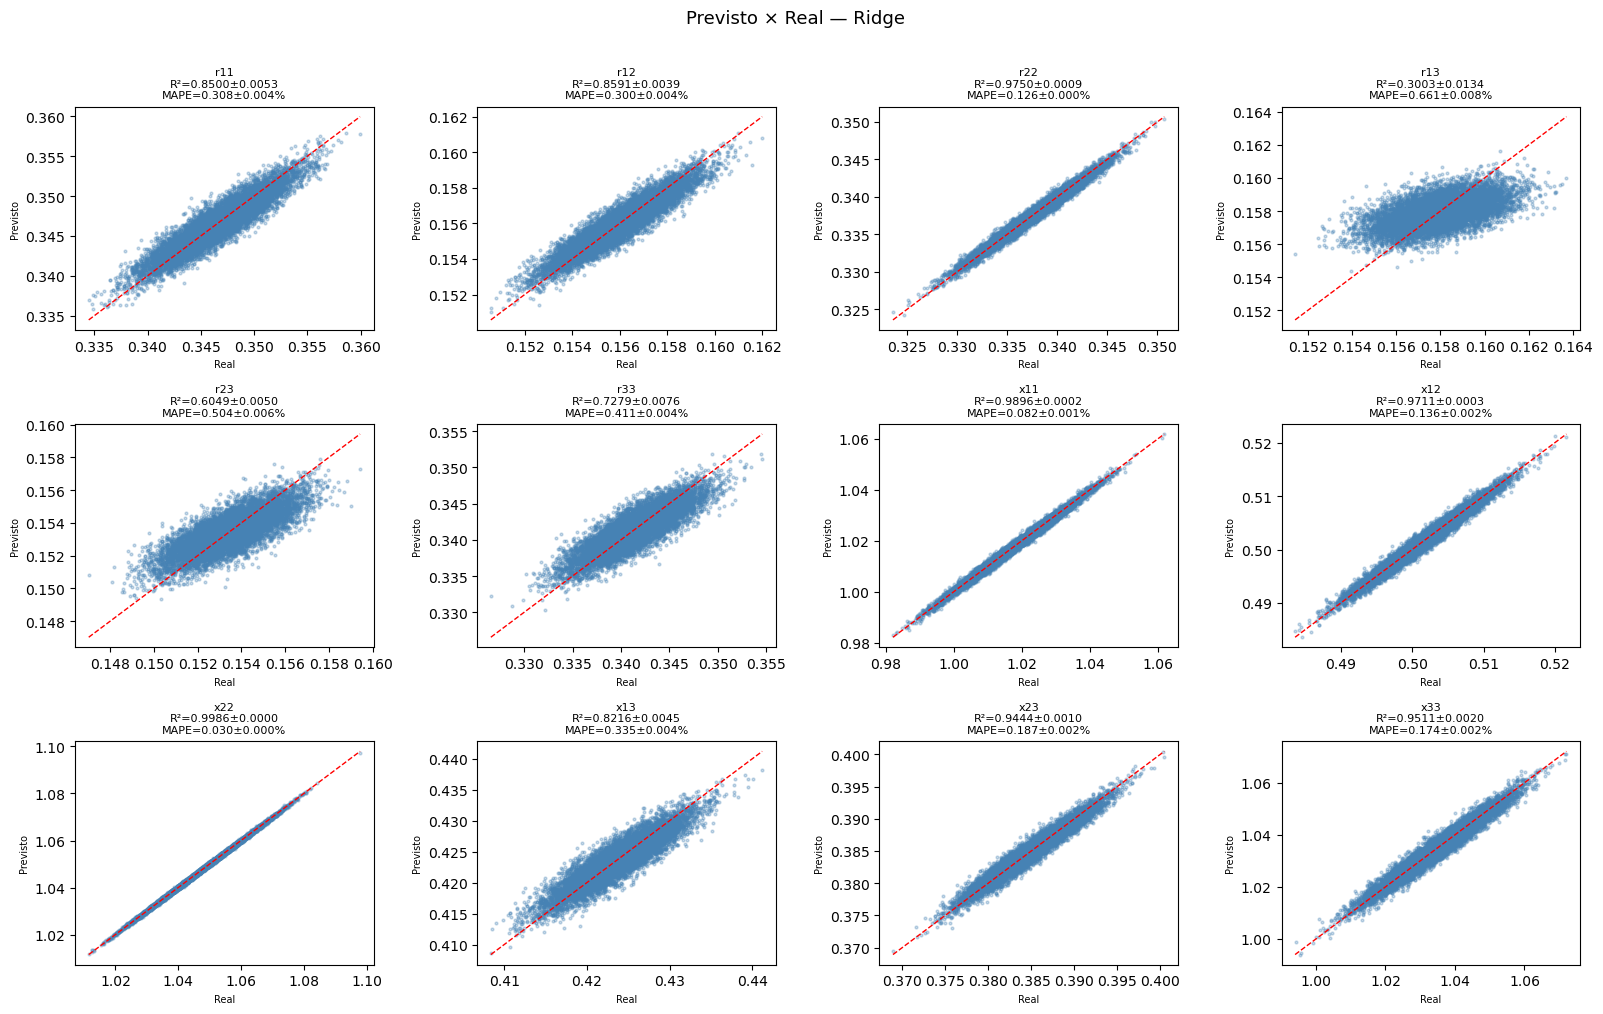

In [12]:
# =========================================================
# Melhor modelo segundo o MAPE médio da validação cruzada
# =========================================================

best_name = min(
    cv_results,
    key=lambda n: cv_results[n]['mape_mean'].mean()
)

print(f'Melhor modelo (menor MAPE médio): {best_name}')
print(f'R² médio   = {cv_results[best_name]["r2_mean"].mean():.4f}')
print(f'MAPE médio = {cv_results[best_name]["mape_mean"].mean():.4f}%')


# =========================================================
# Reajuste do melhor modelo em TODOS os dados
# =========================================================

best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', clone(models[best_name]))
])

best_model.fit(X, y)

y_pred_best = best_model.predict(X)


# =========================================================
# Plot previsto vs real
# =========================================================

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, t in enumerate(TARGETS):

    ax = axes[i]

    ax.scatter(
        y[:, i],
        y_pred_best[:, i],
        s=4,
        alpha=0.3,
        color='steelblue'
    )

    lims = [
        min(y[:, i].min(), y_pred_best[:, i].min()),
        max(y[:, i].max(), y_pred_best[:, i].max())
    ]

    ax.plot(lims, lims, 'r--', lw=1)

    r2_t = cv_results[best_name]['r2_mean'][i]
    r2_s = cv_results[best_name]['r2_std'][i]

    mape_t = cv_results[best_name]['mape_mean'][i]
    mape_s = cv_results[best_name]['mape_std'][i]

    ax.set_title(
        f'{t}\n'
        f'R²={r2_t:.4f}±{r2_s:.4f}\n'
        f'MAPE={mape_t:.3f}±{mape_s:.3f}%',
        fontsize=8
    )

    ax.set_xlabel('Real', fontsize=7)
    ax.set_ylabel('Previsto', fontsize=7)

plt.suptitle(
    f'Previsto × Real — {best_name}',
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.show()

## 7. Distribuição dos erros residuais

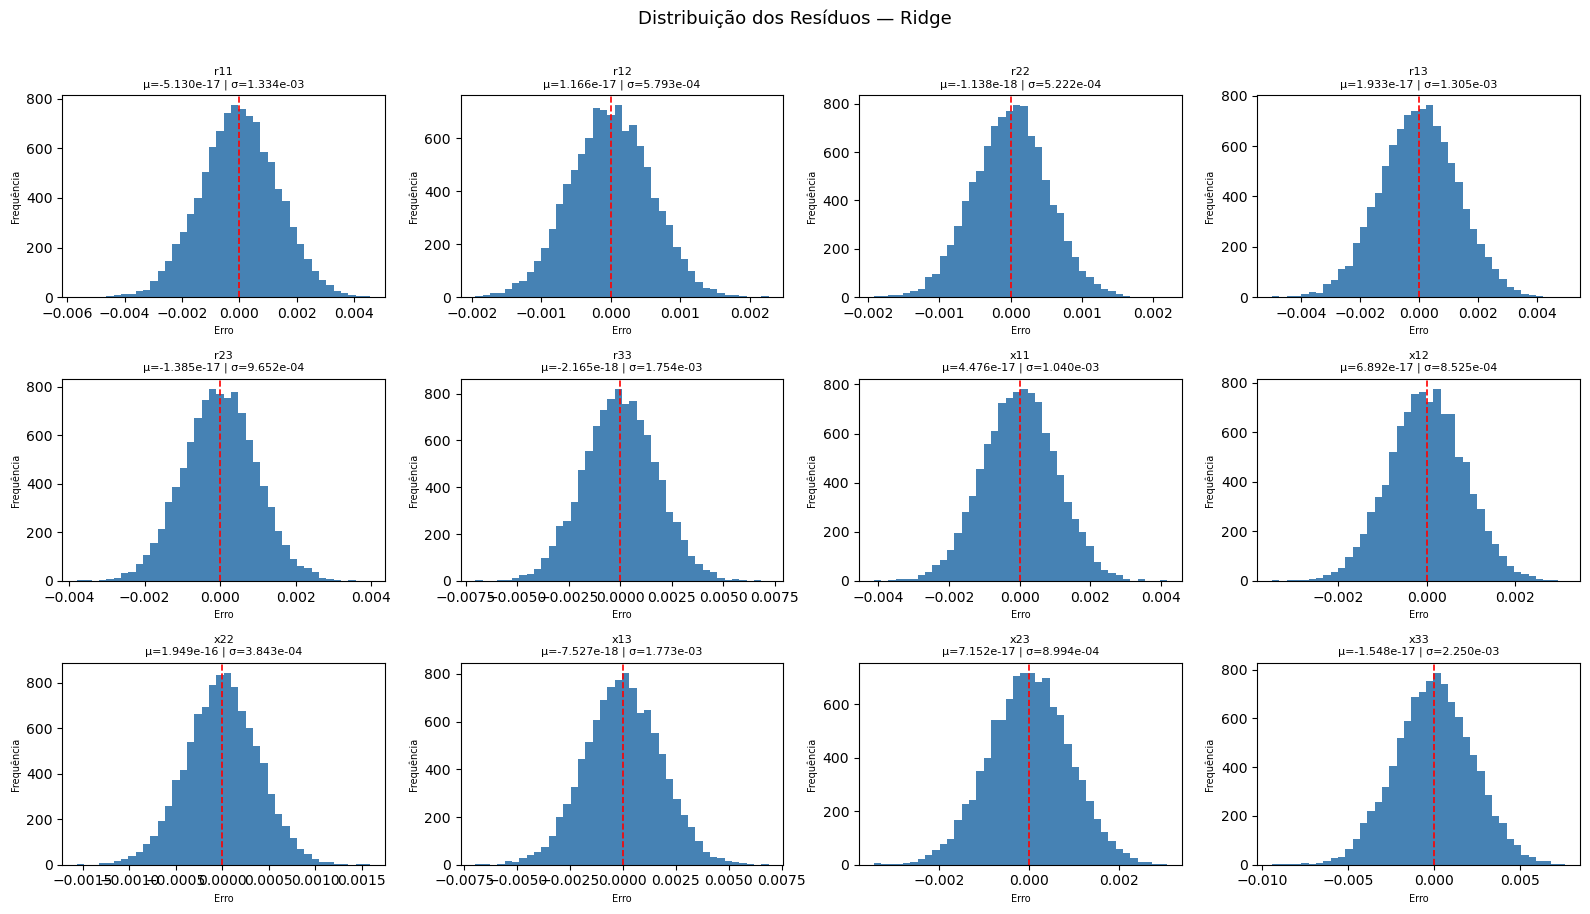

In [13]:
# Resíduos do melhor modelo

best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', clone(models[best_name]))
])

best_model.fit(X, y)

y_pred_best = best_model.predict(X)

# Resíduos
residuals = y - y_pred_best


# =========================================================
# Histogramas dos resíduos
# =========================================================

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

for i, t in enumerate(TARGETS):

    ax = axes[i]

    ax.hist(
        residuals[:, i],
        bins=40,
        color='steelblue',
        edgecolor='none'
    )

    ax.axvline(
        0,
        color='red',
        lw=1.2,
        ls='--'
    )

    mu = residuals[:, i].mean()
    sigma = residuals[:, i].std()

    ax.set_title(
        f'{t}\n'
        f'μ={mu:.3e} | σ={sigma:.3e}',
        fontsize=8
    )

    ax.set_xlabel('Erro', fontsize=7)
    ax.set_ylabel('Frequência', fontsize=7)

plt.suptitle(
    f'Distribuição dos Resíduos — {best_name}',
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.show()

In [14]:
best_name = min(
    cv_results,
    key=lambda n: cv_results[n]['mape_mean'].mean()
)

print(f'Melhor modelo pela validação cruzada: {best_name}')
print(f'CV MAPE médio = {cv_results[best_name]["mape_mean"].mean():.4f}%')
print(f'CV R² médio   = {cv_results[best_name]["r2_mean"].mean():.4f}')


best_model = clone(models[best_name])

best_model.fit(X_train_s, y_train)

y_pred_best = best_model.predict(X_test_s)

r2_test = r2_score(y_test, y_pred_best, multioutput='raw_values')
mae_test = mean_absolute_error(y_test, y_pred_best, multioutput='raw_values')
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_best, multioutput='raw_values'))
mape_test = mape_per_target(y_test, y_pred_best)

print('\nResultado final na base de teste')
print(f'Modelo     = {best_name}')
print(f'R² médio   = {r2_test.mean():.4f}')
print(f'MAE médio  = {mae_test.mean():.6f}')
print(f'RMSE médio = {rmse_test.mean():.6f}')
print(f'MAPE médio = {mape_test.mean():.4f}%')


df_best_test = pd.DataFrame({
    'R2': r2_test,
    'MAE': mae_test,
    'RMSE': rmse_test,
    'MAPE_%': mape_test,
}, index=TARGETS)

display(df_best_test.round(6))

Melhor modelo pela validação cruzada: Ridge
CV MAPE médio = 0.2711%
CV R² médio   = 0.8328

Resultado final na base de teste
Modelo     = Ridge
R² médio   = 0.8363
MAE médio  = 0.000900
RMSE médio = 0.001125
MAPE médio = 0.2678%


,R2,MAE,RMSE,MAPE_%
r11,0.859383,0.001048,0.001316,0.302316
r12,0.865151,0.000464,0.000577,0.297656
r22,0.975737,0.000422,0.000529,0.125236
r13,0.300625,0.001034,0.001292,0.654775
r23,0.609646,0.000763,0.000950,0.497654
r33,0.741011,0.001389,0.001725,0.406962
x11,0.989822,0.000823,0.001022,0.080856
x12,0.970993,0.000671,0.000838,0.133683
x22,0.998601,0.000316,0.000394,0.030133
x13,0.825144,0.001392,0.001741,0.328705


In [15]:
rows = []

for name in models:

    mape_val_cv = cv_results[name]['mape_mean'].mean()
    r2_val_cv   = cv_results[name]['r2_mean'].mean()

    # Treino final no hold-out

    model = clone(models[name])

    model.fit(X_train_s, y_train)

    y_pred_test = model.predict(X_test_s)

    r2_test = r2_score(
        y_test,
        y_pred_test,
        multioutput='raw_values'
    ).mean()

    mape_test = mape_per_target(
        y_test,
        y_pred_test
    ).mean()

    rows.append({
        'Modelo': name,

        'CV MAPE %': round(mape_val_cv, 4),
        'CV R²': round(r2_val_cv, 4),

        'Teste MAPE %': round(mape_test, 4),
        'Teste R²': round(r2_test, 4),
    })

df_summary = pd.DataFrame(rows).set_index('Modelo')

display(df_summary)

,CV MAPE %,CV R²,Teste MAPE %,Teste R²
Modelo,,,,
Ridge,0.2711,0.8328,0.2678,0.8363
RandomForest,0.5198,0.5110,0.5196,0.5130
ExtraTrees,0.5273,0.4973,0.5264,0.4990
GradientBoosting,0.5110,0.5250,0.5092,0.5279
